# Fake News Detector using Machine Learning

This project aims to classify news articles as Fake or Real using Natural Language Processing (NLP) and Machine Learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake News Records:", fake.shape)
print("Real News Records:", true.shape)

Fake News Records: (23481, 4)
Real News Records: (21417, 4)


In [3]:
fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], axis=0)

df = df.sample(frac=1, random_state=42)

df.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 22216 to 15795
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [5]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [6]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

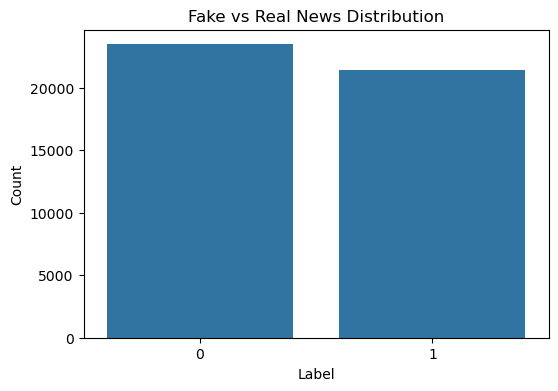

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Fake vs Real News Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [24]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text

In [25]:
df["text"] = df["text"].apply(clean_text)

df["text"].head()

22216    st century wire says ben stein reputable profe...
4436     washington reuters us president donald trump r...
1526     reuters puerto rico governor ricardo rossello ...
1377     on monday donald trump once again embarrassed ...
8995     glasgow scotland reuters most us presidential ...
Name: text, dtype: object

In [36]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [38]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model Training Completed")

Model Training Completed


In [14]:
predictions = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy * 100)

Accuracy : 98.5968819599109


In [16]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



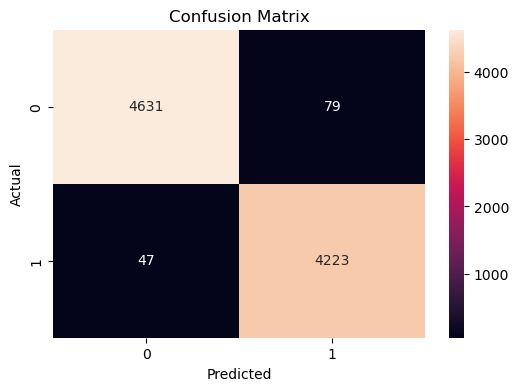

In [17]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
pickle.dump(model, open("model.pkl", "wb"))

pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
news = [
    "Scientists have discovered a new planet similar to Earth."
]

vector = vectorizer.transform(news)

prediction = model.predict(vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News


In [20]:
probability = model.predict_proba(vector)

confidence = max(probability[0]) * 100

print("Confidence Score:", round(confidence,2), "%")

Confidence Score: 90.26 %


In [21]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\91962\Fake_News_Detector_Project
['.ipynb_checkpoints', 'Fake.csv', 'Fake_News_Detection_Model.ipynb', 'model.pkl', 'True.csv', 'vectorizer.pkl']


In [22]:
import shutil

shutil.copy(
    "model.pkl",
    r"D:\pythonProject\FakeNewsDetector\ml_model\model.pkl"
)

shutil.copy(
    "vectorizer.pkl",
    r"D:\pythonProject\FakeNewsDetector\ml_model\vectorizer.pkl"
)

print("Files Copied Successfully")

Files Copied Successfully


In [26]:
test_news = "Scientists at NASA have discovered evidence of water ice on the Moon."

cleaned = clean_text(test_news)

vector = vectorizer.transform([cleaned])

print(model.predict(vector))
print(model.predict_proba(vector))

[0]
[[0.82720856 0.17279144]]
